In [2]:
# Import required libraries for data analysis and visualization
import os, glob, pandas as pd, seaborn as sns, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [3]:
import re

# Load master heatmap CSV files from current directory
csv_files = glob.glob("master_heatmap*.csv")  # Find all CSV files in current directory

def extract_teff_bin(filename):
    match = re.search(r'(\d{4})_(\d{4})_K', filename)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    return None

# Load and combine all CSV files into a single dataframe, adding temperature bin
df = pd.DataFrame()
for f in csv_files:
    temp_bin = extract_teff_bin(f)
    temp_df = pd.read_csv(f)
    temp_df['teff_bin'] = temp_bin
    df = pd.concat([df, temp_df], ignore_index=True)

print(f"Combined dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())



Combined dataframe shape: (336, 7)
Columns: ['radius_bin_center', 'period_bin_center', 'detections', 'trials', 'transit_prob', 'detection_rate', 'teff_bin']
   radius_bin_center  period_bin_center  detections  trials  transit_prob  \
0               1.63           0.700000          32      39      0.242834   
1               1.63           1.213795          32      41      0.167226   
2               1.63           2.104076          28      41      0.120814   
3               1.63           3.647060          35      49      0.082521   
4               1.63           6.322136          17      33      0.056612   

   detection_rate   teff_bin  
0        0.820513  4000_4500  
1        0.780488  4000_4500  
2        0.682927  4000_4500  
3        0.714286  4000_4500  
4        0.515152  4000_4500  


Period values: [ 0.7         1.21379484  2.10407628  3.64706025  6.32213587 10.95991788
 19.00194256]
Period log values: [-0.15490196  0.08414529  0.32306148  0.56194294  0.80086383  1.0398073
  1.278798  ]
Period bin edges: [0.5315870791982804, 0.9217680774690752, 1.5980979107961888, 2.7701431313092457, 4.801792420547086, 8.324066913452322, 14.43120681207672, 25.020348313588052]
Number of bins: 7


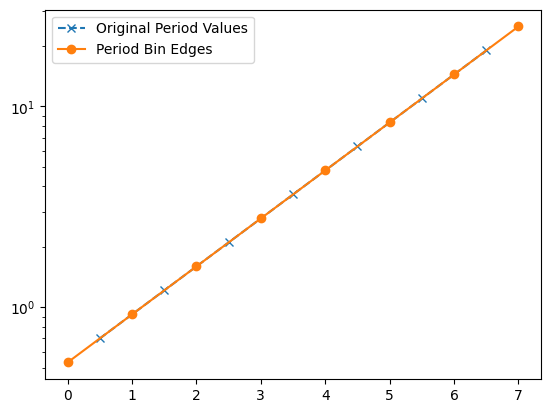

Radius values: [1.63       1.92029811 2.2627294  2.66604942 3.1408662  3.69995705]
Radius log values: [0.2121876  0.28336865 0.35463262 0.4258682  0.49704944 0.56819668]
Radius bin edges: [1.5017480601700404, 1.7692048822751023, 2.084493941393594, 2.45612467265326, 2.8937353874752607, 3.4089690583526253, 4.015783649123488]
Number of bins: 6


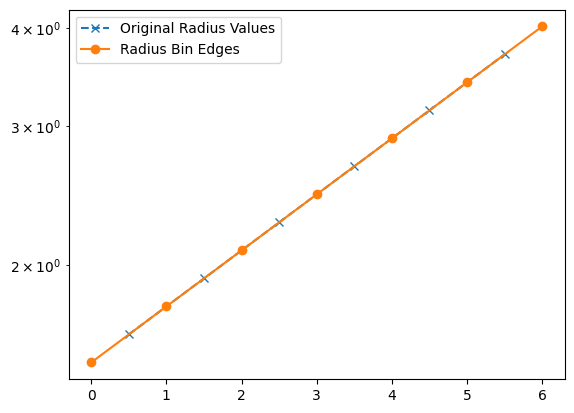

In [4]:
# Generate log-spaced bin edges for True Period values
period_vals = np.array(sorted(df['period_bin_center'].unique()))  # Get unique period values

# Calculate log-space halfway points between adjacent values
period_log = np.log10(period_vals)  # Convert to log space
period_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = period_log[1] - period_log[0]  # Log spacing between first two values
first_edge = 10**(period_log[0] - log_step/2)  # Extrapolate backward by half step
period_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(period_log) - 1):
    halfway_log = (period_log[i] + period_log[i+1]) / 2  # Midpoint in log space
    period_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = period_log[-1] - period_log[-2]  # Log spacing between last two values
last_edge = 10**(period_log[-1] + log_step/2)  # Extrapolate forward by half step
period_bin_edges.append(last_edge)

# Print results for verification
print(f"Period values: {period_vals}")
print(f"Period log values: {period_log}")
print(f"Period bin edges: {period_bin_edges}")
print(f"Number of bins: {len(period_bin_edges) - 1}")

# Plot to visualize period values vs bin edges
period_vals_x_axis = np.arange(len(period_vals)) + 0.5  # Offset for visualization
plt.plot(period_vals_x_axis, period_vals, 'x--', label='Original Period Values')
plt.plot(period_bin_edges, 'o-', label='Period Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()

# Generate log-spaced bin edges for True Radius values (same method as periods)
radius_vals = np.array(sorted(df['radius_bin_center'].unique()))  # Get unique radius values

# Calculate log-space halfway points between adjacent values
radius_log = np.log10(radius_vals)  # Convert to log space
radius_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = radius_log[1] - radius_log[0]  # Log spacing between first two values
first_edge = 10**(radius_log[0] - log_step/2)  # Extrapolate backward by half step
radius_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(radius_log) - 1):
    halfway_log = (radius_log[i] + radius_log[i+1]) / 2  # Midpoint in log space
    radius_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = radius_log[-1] - radius_log[-2]  # Log spacing between last two values
last_edge = 10**(radius_log[-1] + log_step/2)  # Extrapolate forward by half step
radius_bin_edges.append(last_edge)

# Print results for verification
print(f"Radius values: {radius_vals}")
print(f"Radius log values: {radius_log}")
print(f"Radius bin edges: {radius_bin_edges}")
print(f"Number of bins: {len(radius_bin_edges) - 1}")

# Plot to visualize radius values vs bin edges
radius_vals_x_axis = np.arange(len(radius_vals)) + 0.5  # Offset for visualization
plt.plot(radius_vals_x_axis, radius_vals, 'x--', label='Original Radius Values')
plt.plot(radius_bin_edges, 'o-', label='Radius Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()



In [9]:
# Assign bin min/max edges for each row using pd.cut with labels as bin index, then map to edge values
df['radius_bin'] = pd.cut(df['radius_bin_center'], bins=radius_bin_edges, include_lowest=True, labels=False)
df['period_bin'] = pd.cut(df['period_bin_center'], bins=period_bin_edges, include_lowest=True, labels=False)
df['radius_bin_min'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['radius_bin_max'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
df['period_bin_min'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['period_bin_max'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
print(df['radius_bin_max'])

0      1.769205
1      1.769205
2      1.769205
3      1.769205
4      1.769205
         ...   
331    4.015784
332    4.015784
333    4.015784
334    4.015784
335    4.015784
Name: radius_bin_max, Length: 336, dtype: float64


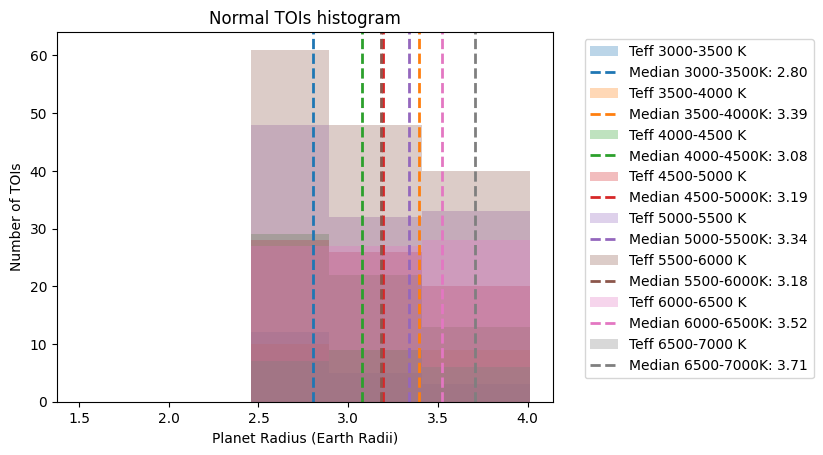

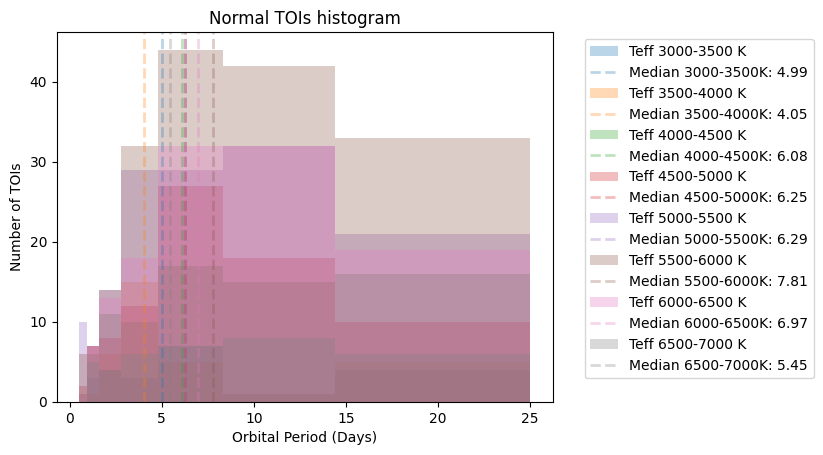

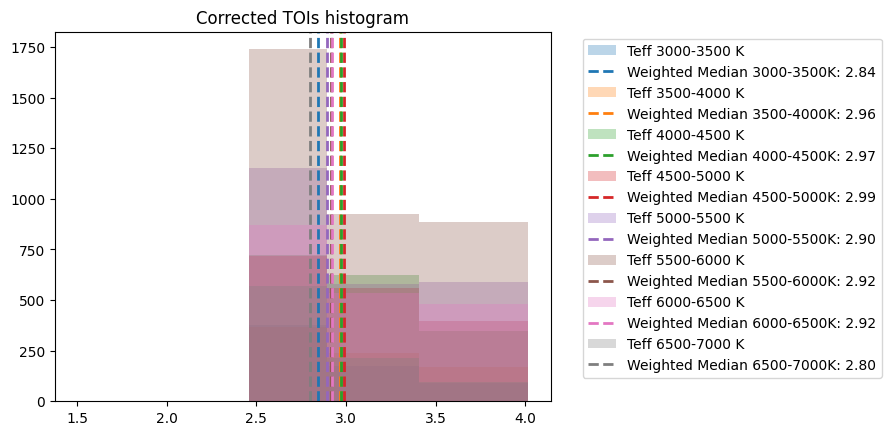

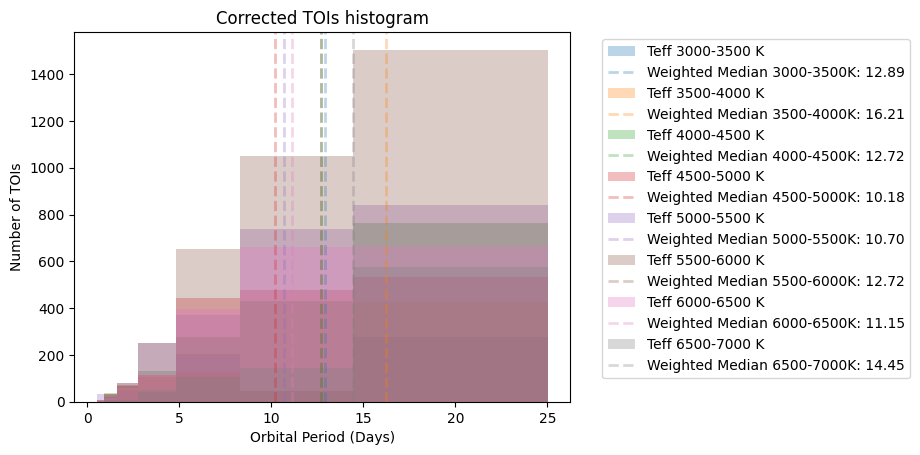

Rows with any NaNs in merged_df: 195
Rows with NaNs in merged_df:
         toi  st_teff   pl_rade  pl_orbper   teff_bin  radius_bin_min  \
1    7008.01   5170.0  4.779190   0.840691  5000_5500             NaN   
2    7045.01   6320.0  4.163510   2.277598  6000_6500             NaN   
11   4410.01   5489.0  2.551262  26.017910  5000_5500        2.456125   
16   5595.01   4119.0  4.716450   5.990051  4000_4500             NaN   
22   6650.03   6500.6  4.260790   8.996513  6500_7000             NaN   
..       ...      ...       ...        ...        ...             ...   
699   422.01   5999.0  4.495709   0.633337  5500_6000             NaN   
702  4303.01   6908.0  4.306368   8.611084  6500_7000             NaN   
705  4365.01   6311.0  4.577220   3.378425  6000_6500             NaN   
711  4534.01   4279.0  4.752720   2.849282  4000_4500             NaN   
717   854.01   5928.0  4.800020   5.850943  5500_6000             NaN   

     radius_bin_max  period_bin_min  period_bin_max  radi

In [8]:
 
TOIs = pd.read_csv('../TOI_Mar2025_0to6_R.csv')

# Define temperature ranges matching our completeness data
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

#teff_ranges = [(t, t + 1000) for t in range(3000, 7000, 1000)]

# Filter TOIs data
TOIs_filtered = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_rade'] > 2.5) & (TOIs_filtered['pl_rade'] < 5.0)]
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_orbper'] > 0.519) & (TOIs_filtered['pl_orbper'] < 30)]
#TOIs_bootstrap = TOIs_bootstrap[~TOIs_bootstrap['toi'].isin([2194.01])] #second try ones with giant corrections

#TOIs_filtered = TOIs_filtered[~TOIs_filtered['id'].isin([80224448, 370009806])] # The ones with giant corrections
#TOIs_filtered = TOIs_filtered[~TOIs_filtered['toi'].isin([2482.01, 2194.01, 2103.02])] #second try ones with giant corrections
TOIs_filtered = TOIs_filtered[~TOIs_filtered['toi'].isin([2194.01])] #second try ones with giant corrections
TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FA']


#TOIs_filtered = TOIs_filtered[(TOIs_filtered['ruwe'] <= 1.4)]

# Remove false positives if column exists
if 'tfopwg_disp' in TOIs_filtered.columns:
    TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FP']

TOIs_filtered = TOIs_filtered[['toi', 'st_teff', 'pl_rade', 'pl_orbper']]

radius_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

period_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]
#print(TOIs_filtered)

#print(radius_bins)
#print(period_bins)

for row in TOIs_filtered.itertuples():
    teff = row.st_teff
    radius = row.pl_rade
    period = row.pl_orbper
    
    # Determine which temperature bin the TOI falls into
    for teff_min, teff_max in teff_ranges:
        if teff_min <= teff < teff_max:
            teff_bin = f"{teff_min}_{teff_max}"
            TOIs_filtered.at[row.Index, 'teff_bin'] = teff_bin
    
    for rad_min, rad_max in radius_bins:
        if rad_min <= radius < rad_max:
            radius_bin_min = rad_min
            radius_bin_max = rad_max
            TOIs_filtered.at[row.Index, 'radius_bin_min'] = radius_bin_min
            TOIs_filtered.at[row.Index, 'radius_bin_max'] = radius_bin_max

    for per_min, per_max in period_bins:
        if per_min <= period < per_max:
            period_bin_min = per_min
            period_bin_max = per_max
            TOIs_filtered.at[row.Index, 'period_bin_min'] = period_bin_min
            TOIs_filtered.at[row.Index, 'period_bin_max'] = period_bin_max

#print(TOIs_filtered)
  
# Merge TOIs with completeness data
merged_df = pd.merge(TOIs_filtered, df, on=['teff_bin', 'radius_bin_min', 'radius_bin_max', 'period_bin_min', 'period_bin_max'], how='left')
#print(merged_df)

#### REGULAR HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_rade'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Planet Radius (Earth Radii)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3, label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_orbper'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()
########

# calculate inverse detection and transit probabilities
for row in merged_df.itertuples():
    detection_rate = row.detection_rate
    transit_prob = row.transit_prob

    # Only update detection_inverse and transit_inverse, leave other columns untouched
    if pd.notnull(detection_rate) and detection_rate > 0:
        merged_df.at[row.Index, 'detection_inverse'] = 1/detection_rate
    else:
        merged_df.at[row.Index, 'detection_inverse'] = np.nan

    if pd.notnull(transit_prob) and transit_prob > 0:
        merged_df.at[row.Index, 'transit_inverse'] = 1/transit_prob
    else:
        merged_df.at[row.Index, 'transit_inverse'] = np.nan
#print(merged_df)

#merged_df to csv
#merged_df[['toi', 'detection_inverse', 'transit_inverse']].to_csv('merged_df.csv', index=False)

# Duplicate each row of merged_df according to a per-row count value in a new column 'row_count'
# First, define how you want to calculate 'weight' for each row. 
# Example: here we use detection_inverse * transit_inverse rounded to nearest int, but you can change this logic.
merged_df['weight'] = (merged_df['detection_inverse'] * merged_df['transit_inverse']).fillna(1)
#merged_df['mult_count'] = np.where(merged_df['mult_count'] >= 1, merged_df['mult_count'] - 1, merged_df['mult_count'])
#print(merged_df[['toi', 'detection_rate', 'transit_prob', 'detection_inverse', 'transit_inverse', 'mult_count']])

#print(merged_df)
#print(merged_df[['toi', 'detection_inverse', 'transit_inverse', 'row_count']])
# Now repeat each row according to its 'row_count' value
#merged_df_corrected = merged_df#.loc[merged_df.index.repeat(merged_df['mult_count'])].reset_index(drop=True)

radius_medians = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)'])
###CORRECTED HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        radius_medians = pd.concat([
            radius_medians,
            pd.DataFrame({
            'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
            'Weighted Median Radius (Earth Radii)': [weighted_median]
            })], ignore_index=True)
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Corrected TOIs histogram')
plt.show()

#radius_medians.to_csv('corrected_medians.csv', index=False)

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Corrected TOIs histogram')
plt.show()
#######

#print how many rows have NaNs in merged_df
print("Rows with any NaNs in merged_df:", merged_df.isnull().any(axis=1).sum())
print("Rows with NaNs in merged_df:")
print(merged_df[merged_df.isnull().any(axis=1)])
print(merged_df)

toi                  122.01     175.02    206.01     210.01     218.02   \
radius_bin_center                                                         
1.630000            0.000000   0.000000  7.089206   0.000000   0.000000   
1.920390            0.000000   0.000000  0.000000   0.000000  56.453983   
2.262692            0.000000   0.000000  0.000000  58.291738   0.000000   
2.665966           29.737288   0.000000  0.000000   0.000000   0.000000   
3.140805            0.000000  26.604361  0.000000   0.000000   0.000000   
3.699957            0.000000   0.000000  0.000000   0.000000   0.000000   

toi                  237.01      256.01     256.02     406.01    454.01   ...  \
radius_bin_center                                                         ...   
1.630000           49.287844    0.000000  24.225414   0.000000   0.00000  ...   
1.920390            0.000000  157.595433   0.000000  56.453983   0.00000  ...   
2.262692            0.000000    0.000000   0.000000   0.000000   0.00000  .

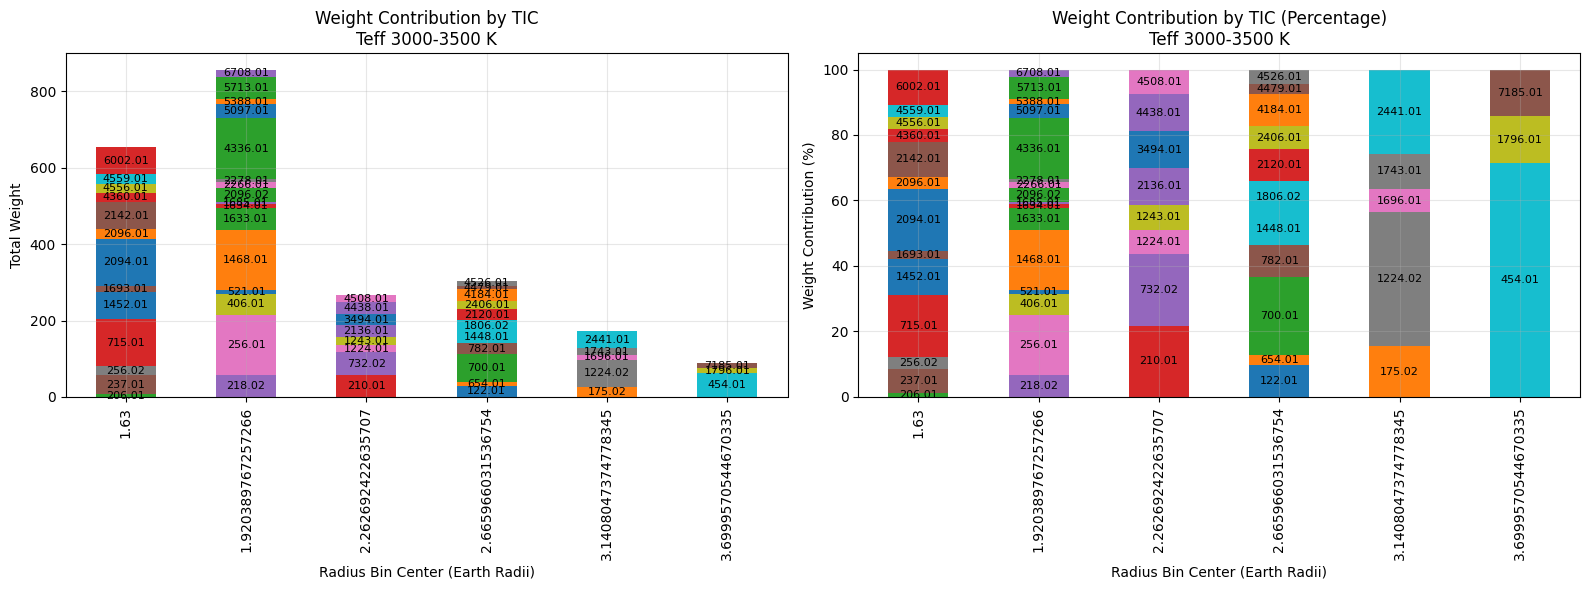


=== Teff 3000-3500 K ===
Total unique TICs: 56
Average weight per radius bin: 390.71

Top 5 TICs by total weight contribution:
  TIC 1468.01: 157.60 (6.7%)
  TIC 256.01: 157.60 (6.7%)
  TIC 4336.01: 157.60 (6.7%)
  TIC 2094.01: 123.91 (5.3%)
  TIC 715.01: 123.91 (5.3%)
toi                  177.01     233.01     233.02     269.01     270.01   \
radius_bin_center                                                          
1.630000            0.000000   0.000000  42.549196   0.000000   0.000000   
1.920390           20.578572  60.043798   0.000000   0.000000   0.000000   
2.262692            0.000000   0.000000   0.000000   0.000000  31.038509   
2.665966            0.000000   0.000000   0.000000   0.000000   0.000000   
3.140805            0.000000   0.000000   0.000000  16.848743   0.000000   
3.699957            0.000000   0.000000   0.000000   0.000000   0.000000   

toi                 270.02     557.01     620.01     663.01     663.02   ...  \
radius_bin_center                       

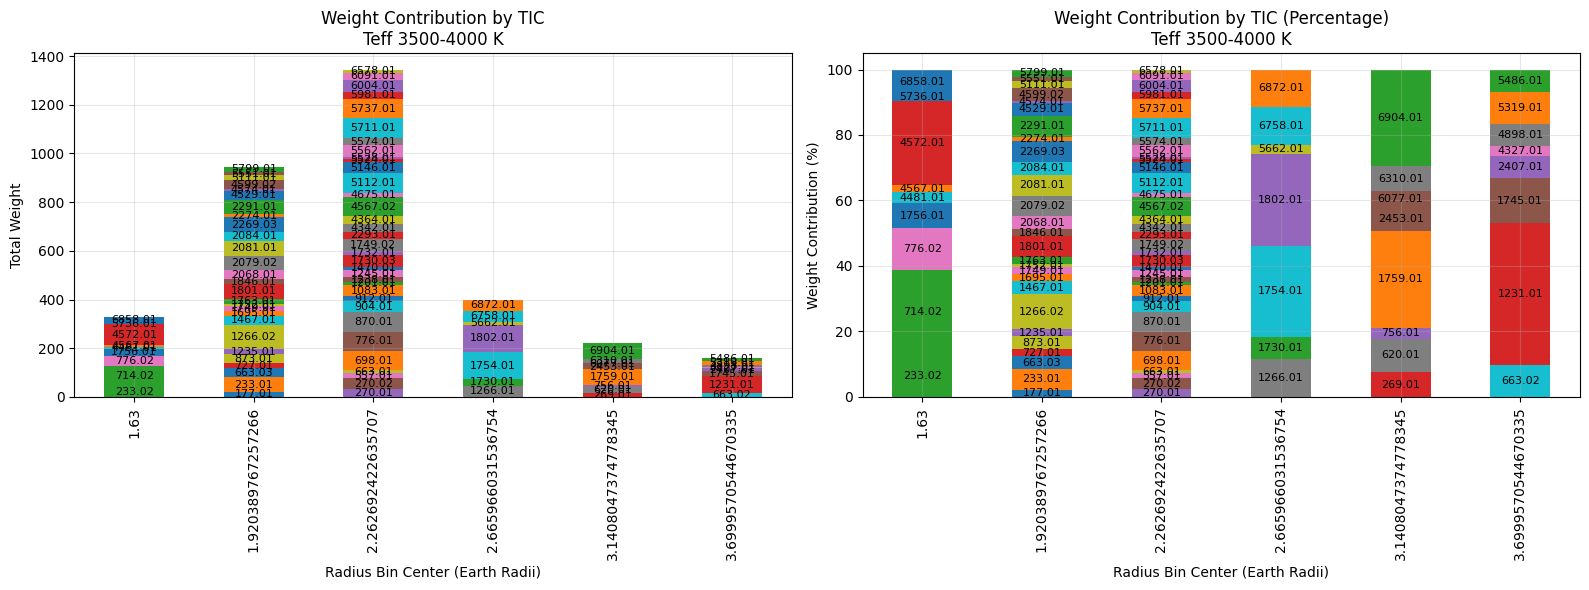


=== Teff 3500-4000 K ===
Total unique TICs: 93
Average weight per radius bin: 566.96

Top 5 TICs by total weight contribution:
  TIC 1754.01: 111.73 (3.3%)
  TIC 1802.01: 111.73 (3.3%)
  TIC 1266.02: 101.25 (3.0%)
  TIC 714.02: 85.22 (2.5%)
  TIC 4572.01: 85.22 (2.5%)
toi                  133.01     178.01     178.02     178.03    178.04   \
radius_bin_center                                                         
1.630000            0.000000   0.000000   0.000000   0.000000  16.96544   
1.920390           26.428673   0.000000   0.000000   0.000000   0.00000   
2.262692            0.000000   0.000000   0.000000  45.213435   0.00000   
2.665966            0.000000  21.631549   0.000000   0.000000   0.00000   
3.140805            0.000000   0.000000   0.000000   0.000000   0.00000   
3.699957            0.000000   0.000000  45.807096   0.000000   0.00000   

toi                  249.01     260.01     279.01     475.01     702.01   ...  \
radius_bin_center                               

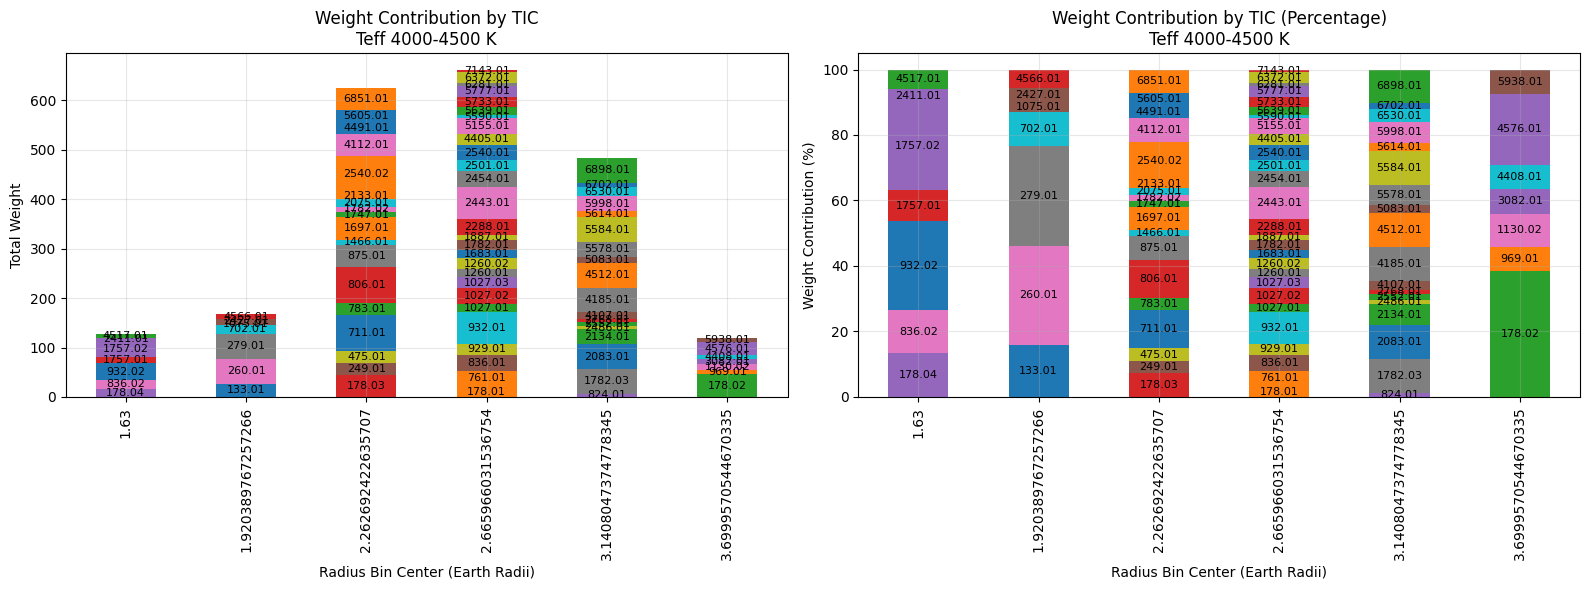


=== Teff 4000-4500 K ===
Total unique TICs: 84
Average weight per radius bin: 364.28

Top 5 TICs by total weight contribution:
  TIC 711.01: 72.74 (3.3%)
  TIC 806.01: 72.74 (3.3%)
  TIC 2540.02: 72.74 (3.3%)
  TIC 932.01: 65.78 (3.0%)
  TIC 2443.01: 65.78 (3.0%)
toi                  174.01     209.01     213.01     431.01     461.01   \
radius_bin_center                                                          
1.630000            0.000000   0.000000   0.000000   0.000000   0.000000   
1.920390           97.051569   0.000000   0.000000   0.000000  53.552812   
2.262692            0.000000  14.714899  69.025755   0.000000   0.000000   
2.665966            0.000000   0.000000   0.000000   0.000000   0.000000   
3.140805            0.000000   0.000000   0.000000  30.373719   0.000000   
3.699957            0.000000   0.000000   0.000000   0.000000   0.000000   

toi                 494.01     533.01    544.01     560.01     560.02   ...  \
radius_bin_center                              

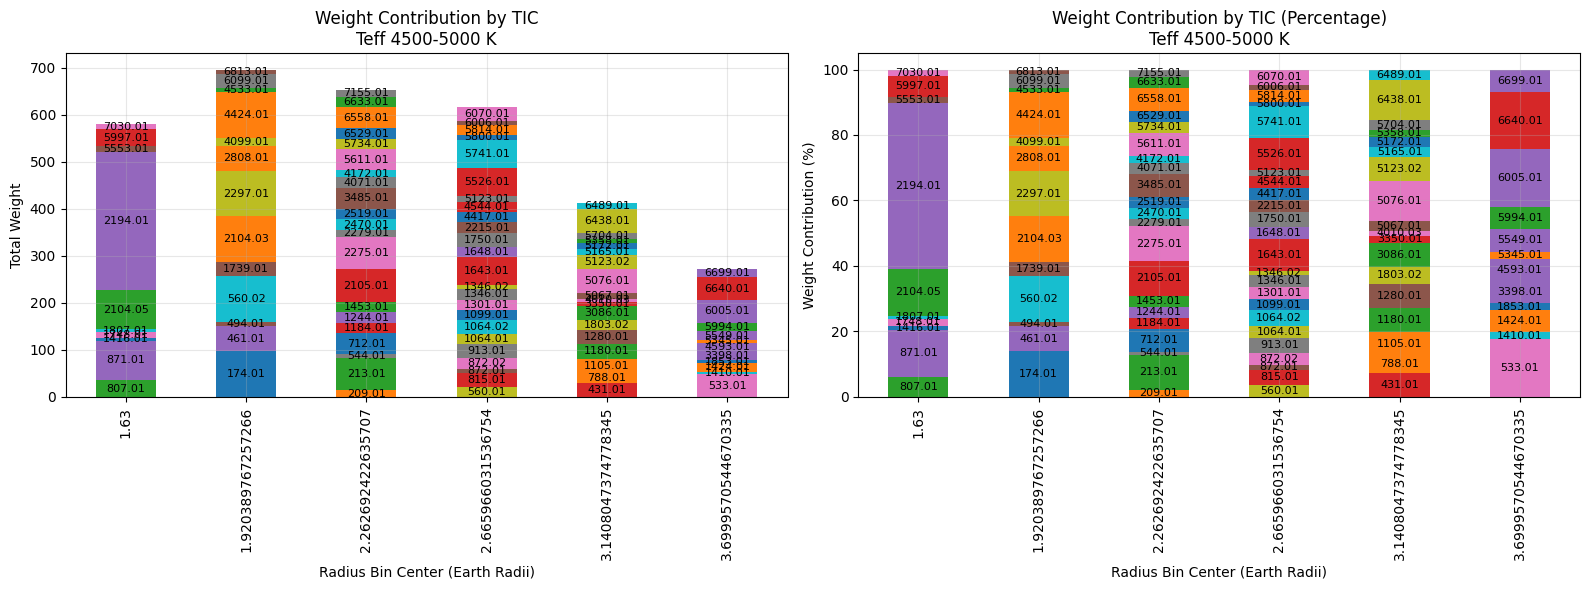


=== Teff 4500-5000 K ===
Total unique TICs: 98
Average weight per radius bin: 538.49

Top 5 TICs by total weight contribution:
  TIC 2194.01: 293.56 (9.1%)
  TIC 560.02: 97.05 (3.0%)
  TIC 2104.03: 97.05 (3.0%)
  TIC 2297.01: 97.05 (3.0%)
  TIC 4424.01: 97.05 (3.0%)
toi                  119.01     119.02     125.01    125.02     125.03   \
radius_bin_center                                                         
1.630000            0.000000   0.000000   0.000000   0.00000   0.000000   
1.920390           27.173778  56.501432   0.000000   0.00000   0.000000   
2.262692            0.000000   0.000000   0.000000   0.00000   0.000000   
2.665966            0.000000   0.000000  12.440311  32.57523  52.772139   
3.140805            0.000000   0.000000   0.000000   0.00000   0.000000   
3.699957            0.000000   0.000000   0.000000   0.00000   0.000000   

toi                  179.01     208.01      214.01    220.01     223.01   ...  \
radius_bin_center                                 

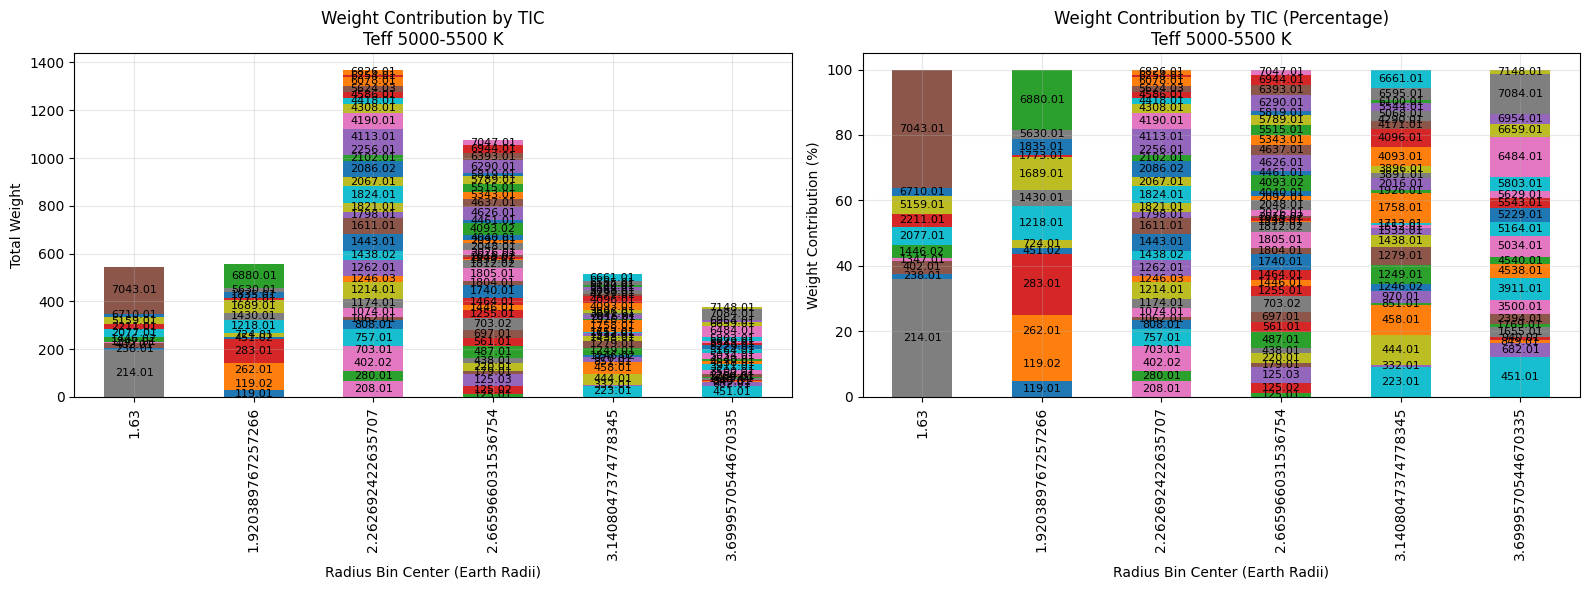


=== Teff 5000-5500 K ===
Total unique TICs: 139
Average weight per radius bin: 739.27

Top 5 TICs by total weight contribution:
  TIC 7043.01: 197.19 (4.4%)
  TIC 214.01: 197.19 (4.4%)
  TIC 283.01: 102.93 (2.3%)
  TIC 6880.01: 102.93 (2.3%)
  TIC 1824.01: 68.94 (1.6%)
toi                132.01    141.01     144.01     248.01     266.01   \
radius_bin_center                                                       
1.630000            0.0000  7.152096   0.000000   0.000000   0.000000   
1.920390            0.0000  0.000000  29.165972   0.000000   0.000000   
2.262692            0.0000  0.000000   0.000000  24.289417  42.365405   
2.665966            0.0000  0.000000   0.000000   0.000000   0.000000   
3.140805            0.0000  0.000000   0.000000   0.000000   0.000000   
3.699957            7.1181  0.000000   0.000000   0.000000   0.000000   

toi                  266.02     421.02    426.01     509.01     509.02   ...  \
radius_bin_center                                               

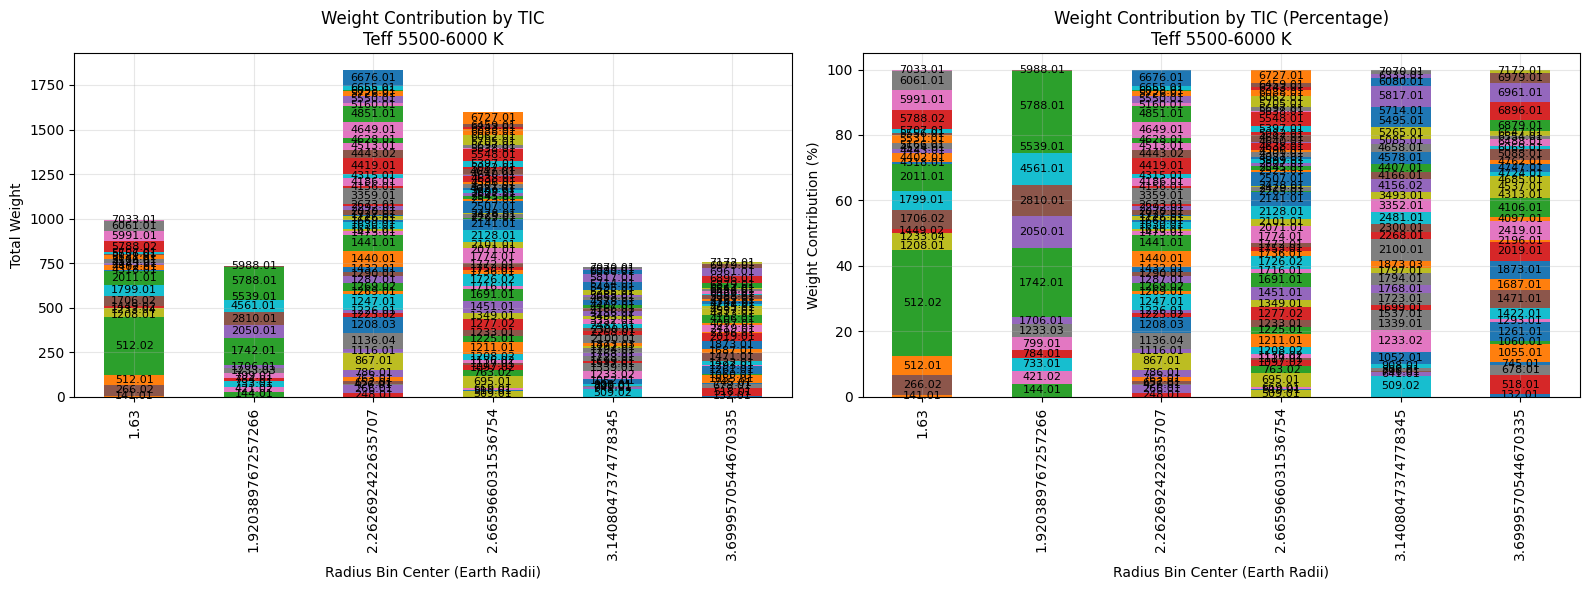


=== Teff 5500-6000 K ===
Total unique TICs: 199
Average weight per radius bin: 1107.67

Top 5 TICs by total weight contribution:
  TIC 512.02: 323.38 (4.9%)
  TIC 5788.01: 154.22 (2.3%)
  TIC 1742.01: 154.22 (2.3%)
  TIC 4649.01: 90.34 (1.4%)
  TIC 867.01: 90.34 (1.4%)
toi                  128.01     130.01    188.01    205.01    271.01   \
radius_bin_center                                                       
1.630000            0.000000   0.000000  0.000000   0.00000  0.000000   
1.920390            0.000000   0.000000  0.000000   0.00000  0.000000   
2.262692           24.171302  44.095547  0.000000  14.70905  0.000000   
2.665966            0.000000   0.000000  0.000000   0.00000  6.800385   
3.140805            0.000000   0.000000  0.000000   0.00000  0.000000   
3.699957            0.000000   0.000000  4.010667   0.00000  0.000000   

toi                  282.04     396.01     396.02      396.03     411.01   \
radius_bin_center                                                  

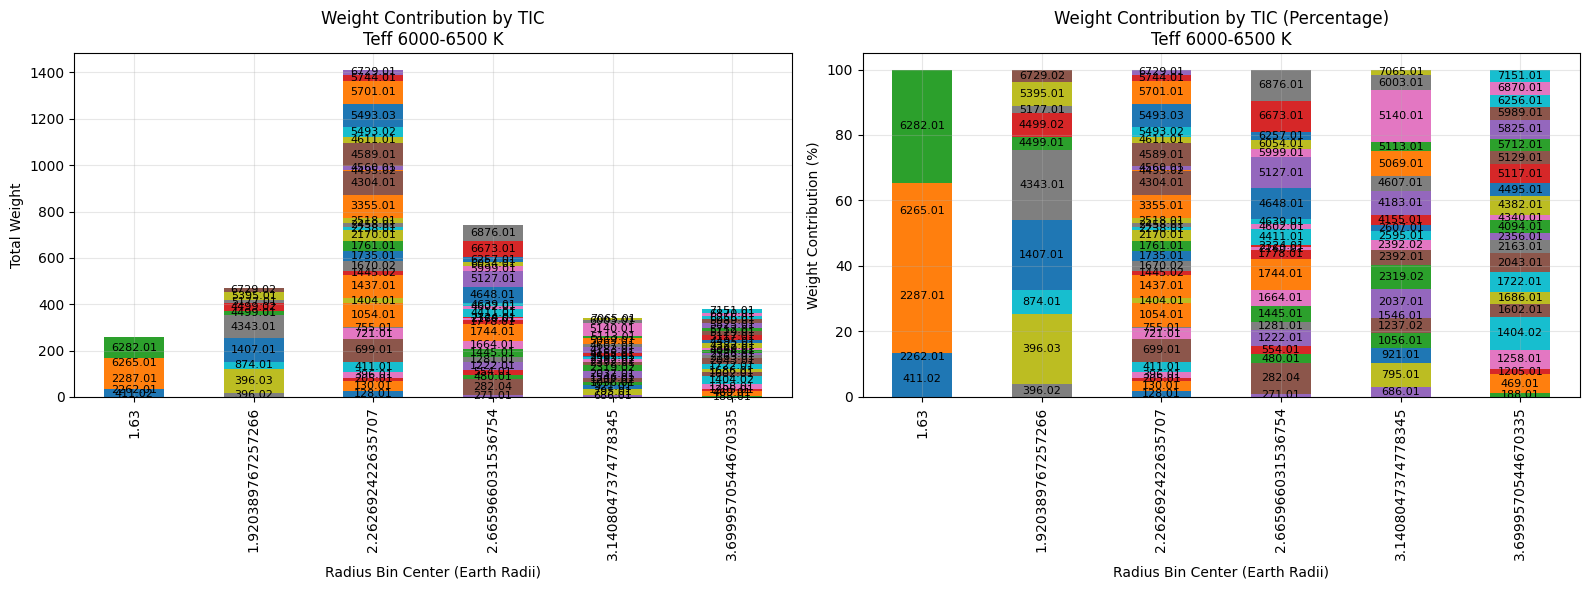


=== Teff 6000-6500 K ===
Total unique TICs: 110
Average weight per radius bin: 599.82

Top 5 TICs by total weight contribution:
  TIC 396.03: 100.64 (2.8%)
  TIC 4343.01: 100.64 (2.8%)
  TIC 1407.01: 100.64 (2.8%)
  TIC 1054.01: 100.22 (2.8%)
  TIC 699.01: 100.22 (2.8%)
toi                  787.01    1204.01    1219.01   1447.01   1620.01  \
radius_bin_center                                                       
1.630000           29.416517  0.000000   0.000000  0.000000  0.000000   
1.920390            0.000000  6.488488  12.437169  0.000000  0.000000   
2.262692            0.000000  0.000000   0.000000  0.000000  8.733655   
2.665966            0.000000  0.000000   0.000000  0.000000  0.000000   
3.140805            0.000000  0.000000   0.000000  0.000000  0.000000   
3.699957            0.000000  0.000000   0.000000  3.588214  0.000000   

toi                   1737.01    2166.01  2465.01    4299.01    4362.01  \
radius_bin_center                                                   

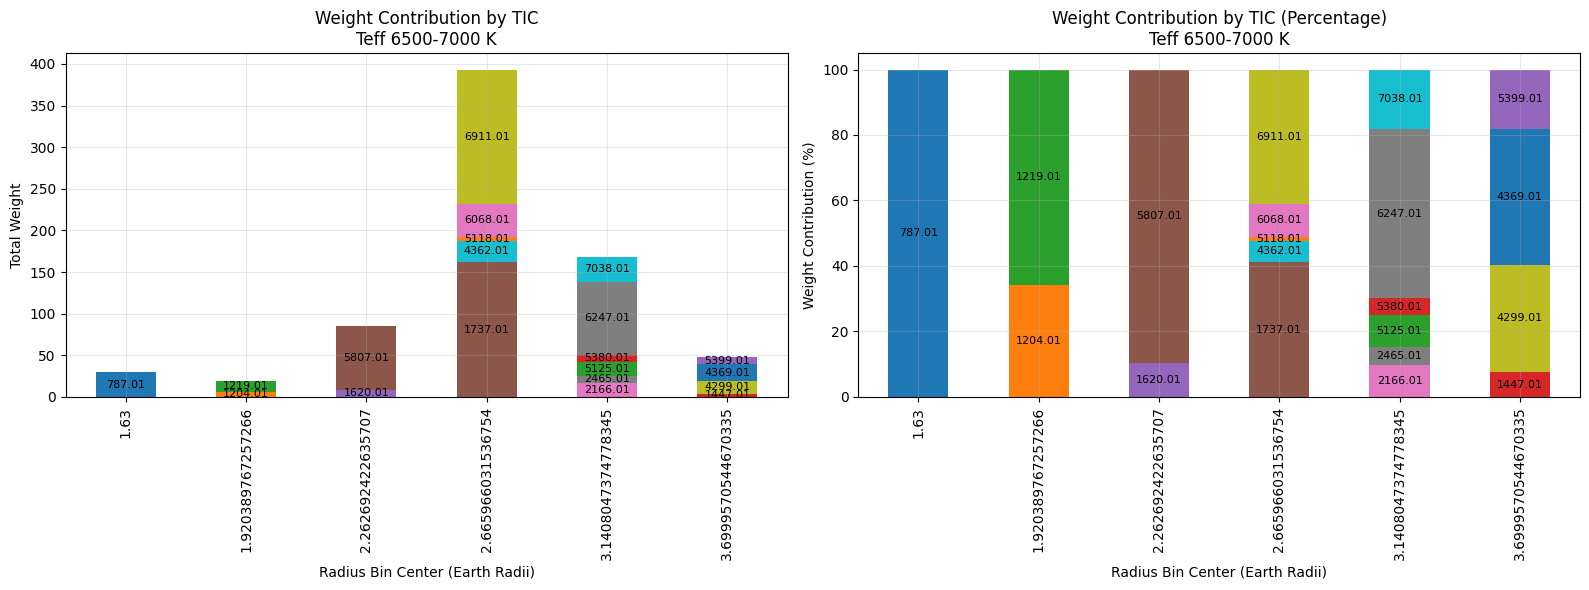


=== Teff 6500-7000 K ===
Total unique TICs: 20
Average weight per radius bin: 123.78

Top 5 TICs by total weight contribution:
  TIC 6911.01: 161.89 (21.8%)
  TIC 1737.01: 161.89 (21.8%)
  TIC 6247.01: 86.80 (11.7%)
  TIC 5807.01: 75.95 (10.2%)
  TIC 6068.01: 38.71 (5.2%)


In [ ]:
#for each radius, I want to know the weight contribution of each tic in a stacked histogram, with percentages

# For each radius bin, show weight contribution of each TIC in a stacked histogram with percentages
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])].copy()
    
    if len(teff_df) == 0:
        continue
    
    # Add radius bin center for grouping
    # Calculate radius bin center in log space
    teff_df['radius_bin_center'] = 10 ** ((np.log10(teff_df['radius_bin_min']) + np.log10(teff_df['radius_bin_max'])) / 2)
    #how does it get the right bins from just the center
    # Create pivot table: rows=radius bins, columns=TICs, values=sum of weights
    pivot = teff_df.pivot_table(
        index='radius_bin_center',
        columns='toi',
        values='weight',
        aggfunc='sum',
        fill_value=0
    )
    print(pivot)
    # Calculate percentage contribution per radius bin
    pivot_percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Absolute weights
    bars1 = pivot.plot(kind='bar', stacked=True, ax=ax1, legend=False)
    ax1.set_xlabel('Radius Bin Center (Earth Radii)')
    ax1.set_ylabel('Total Weight')
    ax1.set_title(f'Weight Contribution by TIC\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax1.grid(True, alpha=0.3)
    
    # Add TIC labels on bars for plot 1
    for i, radius_bin in enumerate(pivot.index):
        cumulative = 0
        for j, toi in enumerate(pivot.columns):
            height = pivot.loc[radius_bin, toi]
            if height > 0:  # Only label if there's a contribution
                ax1.text(i, cumulative + height/2, f'{toi:.2f}', 
                        ha='center', va='center', fontsize=8, rotation=0)
                cumulative += height
    
    # Plot 2: Percentage weights
    bars2 = pivot_percent.plot(kind='bar', stacked=True, ax=ax2, legend=False)
    ax2.set_xlabel('Radius Bin Center (Earth Radii)')
    ax2.set_ylabel('Weight Contribution (%)')
    ax2.set_title(f'Weight Contribution by TIC (Percentage)\nTeff {temp_range[0]}-{temp_range[1]} K')
    ax2.grid(True, alpha=0.3)
    
    # Add TIC labels on bars for plot 2
    for i, radius_bin in enumerate(pivot_percent.index):
        cumulative = 0
        for j, toi in enumerate(pivot_percent.columns):
            height = pivot_percent.loc[radius_bin, toi]
            if height > 0:  # Only label if there's a contribution
                ax2.text(i, cumulative + height/2, f'{toi:.2f}', 
                        ha='center', va='center', fontsize=8, rotation=0)
                cumulative += height
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== Teff {temp_range[0]}-{temp_range[1]} K ===")
    print(f"Total unique TICs: {len(pivot.columns)}")
    print(f"Average weight per radius bin: {pivot.sum(axis=1).mean():.2f}")
    print("\nTop 5 TICs by total weight contribution:")
    top_tics = pivot.sum(axis=0).sort_values(ascending=False).head(5)
    for tic, weight in top_tics.items():
        print(f"  TIC {tic}: {weight:.2f} ({weight/pivot.sum().sum()*100:.1f}%)")

790 TOIs for bootstrapping


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


   Teff Range  Weighted Median Radius (Earth Radii)  \
0  3000-3500K                              2.013576   
1  3500-4000K                              2.200718   
2  4000-4500K                              2.592463   
3  4500-5000K                              2.324413   
4  5000-5500K                              2.430400   
5  5500-6000K                              2.419420   
6  6000-6500K                              2.434320   
7  6500-7000K                              2.797790   

   Weighted Median Error (Earth Radii)  
0                             0.066869  
1                             0.055743  
2                             0.083524  
3                             0.074188  
4                             0.047009  
5                             0.057748  
6                             0.033178  
7                             0.063523  


(-0.0, 0.07)

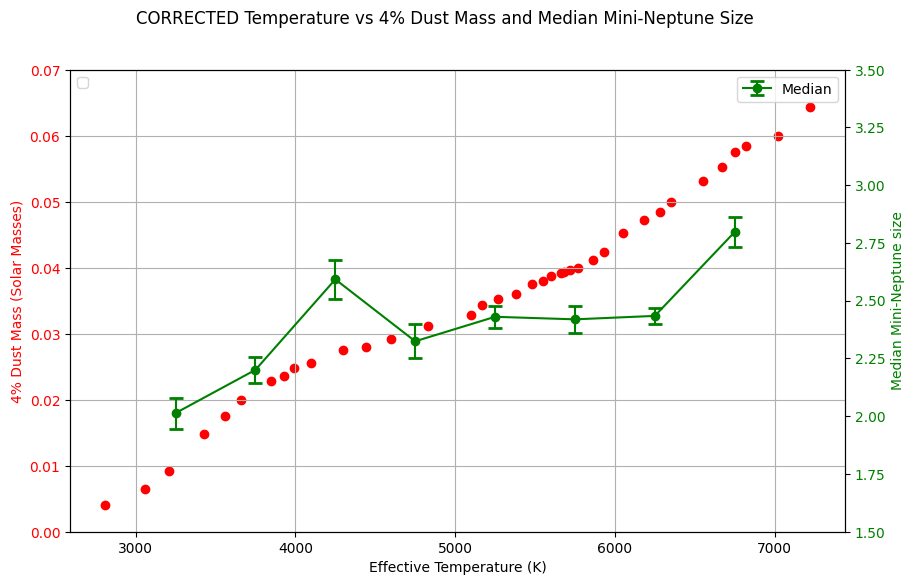

In [ ]:
n_bootstrap = 1000
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

# Calculate bootstrapping errors for weighted medians
def calculate_weighted_median(vals, weights):
    """Calculate weighted median"""
    if len(vals) == 0 or weights.sum() == 0:
        return np.nan
    sorted_idx = np.argsort(vals)
    vals_sorted = vals[sorted_idx]
    weights_sorted = weights[sorted_idx]
    cumsum = np.cumsum(weights_sorted)
    cutoff = weights_sorted.sum() / 2.0
    return vals_sorted[np.searchsorted(cumsum, cutoff)]

# Load TOI data for bootstrapping
TOIs_bootstrap = TOIs_filtered
TOIs_bootstrap = TOIs_bootstrap.dropna(subset=['st_teff', 'pl_rade'])
TOIs_bootstrap = TOIs_bootstrap[(TOIs_bootstrap['pl_rade'] > 1.5) & (TOIs_bootstrap['pl_rade'] < 4.0)]
TOIs_bootstrap = TOIs_bootstrap[(TOIs_bootstrap['pl_orbper'] > 0.519) & (TOIs_bootstrap['pl_orbper'] <30)]
#TOIs_bootstrap = TOIs_bootstrap[TOIs_bootstrap['tfopwg_disp'] == 'FP']


print(len(TOIs_bootstrap), "TOIs for bootstrapping")
if 'tfopwg_disp' in TOIs_bootstrap.columns:
    TOIs_bootstrap = TOIs_bootstrap[TOIs_bootstrap['tfopwg_disp'] != 'FP']

# Calculate weighted median errors using bootstrapping
#print(teff_ranges)
weighted_median_errors = []
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    
    # Get original data for this temperature bin
    bin_mask = (TOIs_bootstrap['st_teff'] >= temp_range[0]) & (TOIs_bootstrap['st_teff'] < temp_range[1])
    toi_indices = TOIs_bootstrap.loc[bin_mask].index
    n_tois = len(toi_indices)
    
    if n_tois == 0:
        weighted_median_errors.append(np.nan)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        # Resample TOI indices with replacement
        bootstrap_indices = np.random.choice(toi_indices, size=n_tois, replace=True)
        
        # Get corresponding rows from merged_df for these TOIs
        bootstrap_teff_df = merged_df[merged_df['toi'].isin(TOIs_bootstrap.loc[bootstrap_indices, 'toi'])]
        bootstrap_teff_df = bootstrap_teff_df[(bootstrap_teff_df['st_teff'] >= temp_range[0]) & 
                                               (bootstrap_teff_df['st_teff'] < temp_range[1])]
        
        if len(bootstrap_teff_df) > 0:
            vals = bootstrap_teff_df['pl_rade'].values
            weights = bootstrap_teff_df['weight'].values
            bootstrap_median = calculate_weighted_median(vals, weights)
            bootstrap_medians.append(bootstrap_median)
    
    median_error = np.std(bootstrap_medians)
    weighted_median_errors.append(median_error)
    #print(weighted_median_errors)
    #print(f"Teff {temp_range[0]}-{temp_range[1]} K: N={n_tois}, Error={median_error:.3f} R_Earth")

# Add errors to radius_medians dataframe
radius_medians['Weighted Median Error (Earth Radii)'] = weighted_median_errors
print(radius_medians)
#print(radius_medians)

fig, ax1 = plt.subplots(figsize=(10, 6))



median_df = radius_medians#
#print(median_df)

median_df['Teff Range Average'] = median_df['Teff Range'].apply(
    lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
)

corrected_mean_median_df = median_df
# corrected_mean_median_df['Teff Range Average'] = corrected_mean_median_df['Teff Range'].apply(
#     lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
# )

# Create a secondary y-axis for Median
ax2 = ax1.twinx()
ax2.errorbar(corrected_mean_median_df['Teff Range Average'], 
             corrected_mean_median_df['Weighted Median Radius (Earth Radii)'], 
             yerr=corrected_mean_median_df['Weighted Median Error (Earth Radii)'],
             color='g', label='Median', marker='o', linestyle='-', capsize=5, capthick=2)
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(1.5,3.50)

# Add a title and legend
fig.suptitle('CORRECTED Temperature vs 4% Dust Mass and Median Mini-Neptune Size')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')





data = {
    'Stellar Type': ['M0V', 'M1V', 'M2V', 'M3V', 'M4V', 'M5V', 'M6V', 'K0V', 'K1V', 'K2V', 'K3V', 'K4V', 'K5V', 'K6V', 'K7V', 'K8V', 'K9V',
                     'G0V', 'G1V', 'G2V', 'G3V', 'G4V', 'G5V', 'G6V', 'G7V', 'G8V', 'G9V',
                     'F0V', 'F1V', 'F2V', 'F3V', 'F4V', 'F5V', 'F6V', 'F7V', 'F8V', 'F9V'],
    'Mass': [0.57, 0.50, 0.44, 0.37, 0.23, 0.162, 0.102, 0.88, 0.86, 0.82, 0.78, 0.73, 0.70, 0.69, 0.64, 0.62, 0.59,
             1.06, 1.03, 1.00, 0.99, 0.985, 0.98, 0.97, 0.95, 0.94, 0.90,
             1.61, 1.50, 1.46, 1.44, 1.38, 1.33, 1.25, 1.21, 1.18, 1.13],
    'Radius': [0.588, 0.501, 0.446, 0.361, 0.274, 0.196, 0.137, 0.813, 0.797, 0.783, 0.755, 0.713, 0.701, 0.669, 0.630, 0.615, 0.608,
               1.100, 1.060, 1.012, 1.002, 0.991, 0.977, 0.949, 0.927, 0.914, 0.853,
               1.728, 1.679, 1.622, 1.578, 1.533, 1.473, 1.359, 1.324, 1.221, 1.167],
    'Luminosity': [0.069, 0.041, 0.029, 0.016, 7.2e-3, 3.0e-3, 1.0e-3, 0.46, 0.41, 0.37, 0.28, 0.20, 0.17, 0.14, 0.10, 0.087, 0.079,
                   1.35, 1.20, 1.02, 0.98, 0.91, 0.89, 0.79, 0.74, 0.68, 0.55,
                   7.24, 6.17, 5.13, 4.68, 4.17, 3.63, 2.69, 2.45, 1.95, 1.66],
    'Effective Temperature': [3850, 3660, 3560, 3430, 3210, 3060, 2810, 5270, 5170, 5100, 4830, 4600, 4440, 4300, 4100, 3990, 3930,
                              5930, 5860, 5770, 5720, 5680, 5660, 5600, 5550, 5480, 5380,
                              7220, 7020, 6820, 6750, 6670, 6550, 6350, 6280, 6180, 6050],
    'B-V Index': [1.42, 1.49, 1.51, 1.53, 1.65, 1.83, 2.01, 0.82, 0.86, 0.88, 0.99, 1.09, 1.15, 1.24, 1.34, 1.36, 1.40,
                  0.60, 0.62, 0.65, 0.66, 0.67, 0.68, 0.70, 0.71, 0.73, 0.78,
                  0.30, 0.33, 0.37, 0.39, 0.41, 0.44, 0.49, 0.50, 0.53, 0.56]
}
data['4% Dust Mass'] = [mass * 0.04 for mass in data['Mass']]
data['1/R^2'] = [1 / (radius ** 2) for radius in data['Radius']]

stellar_df = pd.DataFrame(data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)



# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00,.07)
#ax1.set_ylim(-.01,.0)



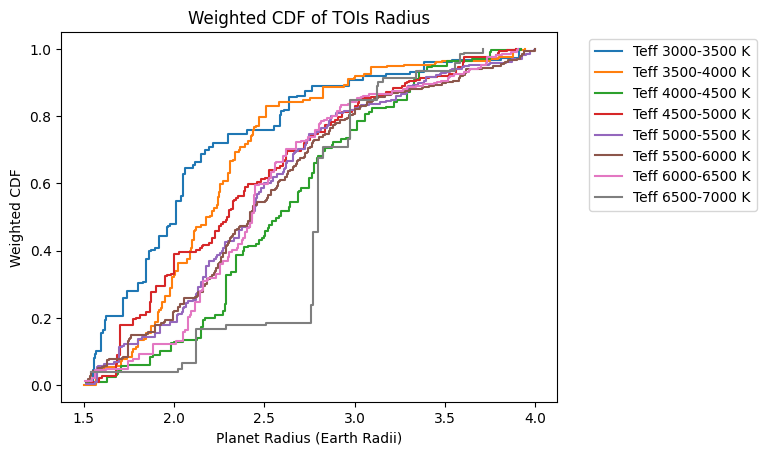

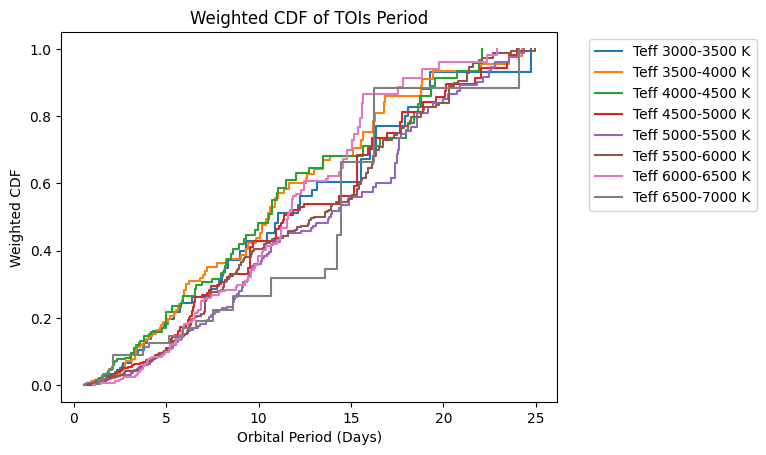

In [ ]:
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Radius')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sort_idx = np.argsort(vals)
        vals_sorted = vals[sort_idx]
        weights_sorted = weights[sort_idx]
        cdf = np.cumsum(weights_sorted) / weights_sorted.sum()
        plt.step(vals_sorted, cdf, where='post', label=f'Teff {temp_range[0]}-{temp_range[1]} K')
plt.xlabel('Orbital Period (Days)')
plt.ylabel('Weighted CDF')
plt.title('Weighted CDF of TOIs Period')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


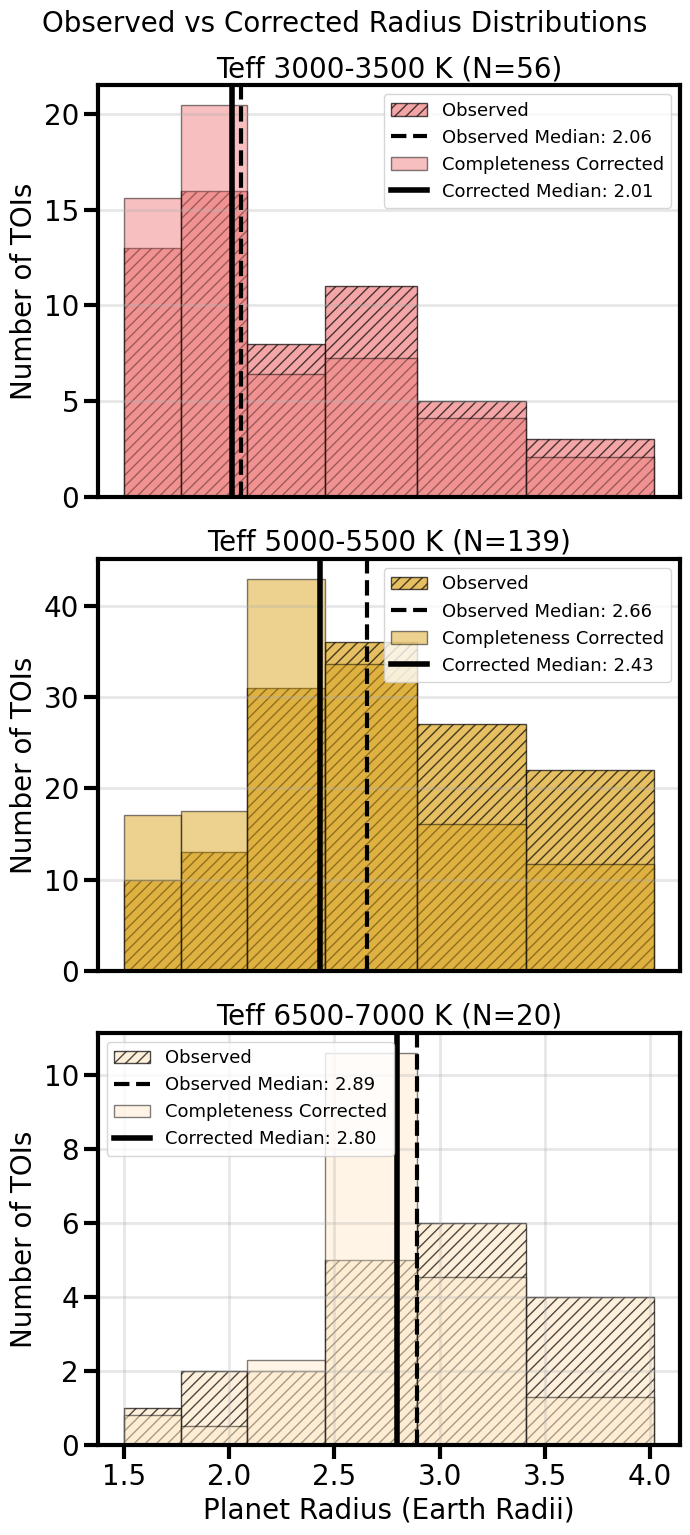

In [ ]:
#### COMBINED RADIUS HISTOGRAMS - Three vertical panels ####
fig, axes = plt.subplots(3, 1, figsize=(7, 15))
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges = [(3000, 3500), (5000, 5500), (6500, 7000)]
for i, temp_range in enumerate(teff_ranges):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

    ax.set_ylabel('Number of TOIs', fontsize=20)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    if i < 2:
        ax.xaxis.set_ticks([])      # Remove x tick marks for top two panels
        ax.set_xlabel('')           # Remove x axis label for top two panels
    else:
        ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
plt.subplots_adjust(hspace=0)  # Negative hspace to make plots overlap vertically
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')

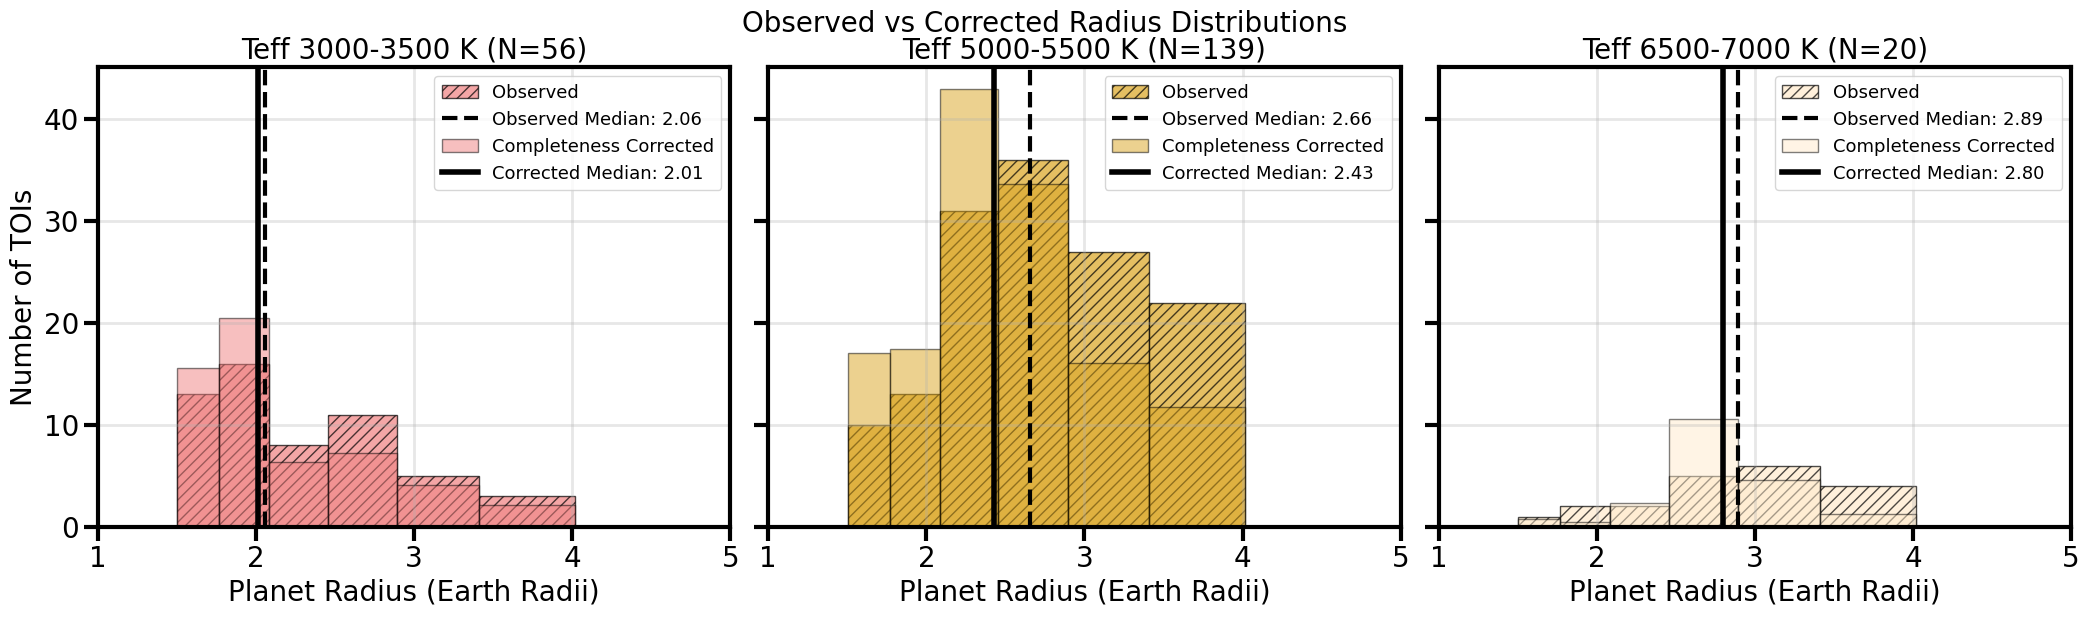

In [ ]:
#### COMBINED RADIUS HISTOGRAMS - Three horizontal panels ####
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
# Define colors for each temperature range
colors = ['lightcoral', 'goldenrod', 'blanchedalmond']
teff_ranges = [(3000, 3500), (5000, 5500), (6500, 7000)]
for i, temp_range in enumerate(teff_ranges):
    ax = axes[i]
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]

    if len(teff_df) > 0:
        # Normal histogram (hatched)
        n_normal, bins_normal, patches_normal = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.7, 
            label='Observed', 
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch='///'  # Diagonal hatching for observed
        )

        # Calculate and plot normal median
        normal_median = teff_df['pl_rade'].median()
        ax.axvline(normal_median, linestyle='--', linewidth=3, color='black', 
                  label=f'Observed Median: {normal_median:.2f}')

        # Calculate normalized weights for corrected histogram
        # Scale weights so total weighted count equals total observed count
        weights = teff_df['weight'].values
        total_weight = weights.sum()
        n_observed = len(teff_df)
        normalized_weights = weights * (n_observed / total_weight) if total_weight > 0 else weights

        # Corrected histogram (solid)
        n_corrected, bins_corrected, patches_corrected = ax.hist(
            teff_df['pl_rade'], 
            bins=radius_bin_edges, 
            alpha=0.5, 
            label='Completeness Corrected', 
            weights=normalized_weights,
            color=colors[i],
            edgecolor='black',
            linewidth=1
        )

        # Calculate and plot weighted median (using original weights for median calculation)
        vals = teff_df['pl_rade'].values
        original_weights = teff_df['weight'].values
        if len(vals) > 0 and original_weights.sum() > 0:
            sorted_idx = np.argsort(vals)
            vals_sorted = vals[sorted_idx]
            weights_sorted = original_weights[sorted_idx]
            cumsum = np.cumsum(weights_sorted)
            cutoff = weights_sorted.sum() / 2.0
            weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            ax.axvline(weighted_median, linestyle='-', linewidth=4, color='black', 
                      label=f'Corrected Median: {weighted_median:.2f}')

    ax.set_xlabel('Planet Radius (Earth Radii)', fontsize=20)
    ax.set_xlim(1, 5.0)
    ax.set_title(f'Teff {temp_range[0]}-{temp_range[1]} K (N={len(teff_df)})', fontsize=20)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3, linewidth=2)
    ax.tick_params(axis='both', which='major', width=3, length=10, labelsize=20)
    ax.tick_params(axis='both', which='minor', width=2, length=6, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    
    # Only show y-axis label on leftmost panel
    if i == 0:
        ax.set_ylabel('Number of TOIs', fontsize=20)

plt.subplots_adjust(wspace=0.05)  # Small spacing between horizontal panels
plt.tight_layout()
plt.suptitle('Observed vs Corrected Radius Distributions', y=1.02, fontsize=20)
plt.show()

# Save the figure to a PNG file
fig.savefig("combined_radius_histograms.png", dpi=300, bbox_inches='tight')